In [1]:
import pandas as pd
import numpy as np


class Backtester:
    def __init__(
        self,
        prices: pd.DataFrame,
        top_n: int = 10,
        rebalance_freq: str = "M",
        transaction_cost: float = 0.001,
    ):
        """
        prices: 종목별 종가 DataFrame
                index = 날짜, columns = 종목코드
        top_n: 매수할 상위 종목 수
        rebalance_freq: 리밸런싱 주기 ("W", "M", "Q")
        transaction_cost: 거래비용, 0.001 = 0.1%
        """
        self.prices = prices.sort_index()
        self.returns = self.prices.pct_change()
        self.top_n = top_n
        self.rebalance_freq = rebalance_freq
        self.transaction_cost = transaction_cost

    def make_signal(self, lookback: int = 60):
        """
        모멘텀 시그널:
        최근 lookback일 수익률이 높은 종목을 선호
        """
        momentum = self.prices.pct_change(lookback)
        return momentum

    def make_weights(self, signal: pd.DataFrame):
        """
        매 리밸런싱 시점마다 상위 top_n 종목 동일비중
        """
        rebalance_dates = (
            signal.resample(self.rebalance_freq)
            .last()
            .dropna(how="all")
            .index
        )

        weights = pd.DataFrame(
            0.0,
            index=self.prices.index,
            columns=self.prices.columns
        )

        for date in rebalance_dates:
            if date not in signal.index:
                continue

            scores = signal.loc[date].dropna()
            selected = scores.nlargest(self.top_n).index

            if len(selected) > 0:
                weights.loc[date, selected] = 1 / len(selected)

        weights = weights.replace(0, np.nan).ffill().fillna(0)
        return weights

    def run(self, lookback: int = 60):
        signal = self.make_signal(lookback)
        weights = self.make_weights(signal)

        # 미래 수익률 누수 방지: 오늘 만든 비중은 다음 날부터 적용
        shifted_weights = weights.shift(1).fillna(0)

        gross_return = (shifted_weights * self.returns).sum(axis=1)

        # 거래비용 계산
        turnover = weights.diff().abs().sum(axis=1)
        cost = turnover * self.transaction_cost

        net_return = gross_return - cost

        result = pd.DataFrame({
            "gross_return": gross_return,
            "cost": cost,
            "net_return": net_return,
            "cum_return": (1 + net_return).cumprod()
        })

        return result, weights

    def performance(self, returns: pd.Series):
        ann_return = (1 + returns).prod() ** (252 / len(returns)) - 1
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

        cum = (1 + returns).cumprod()
        peak = cum.cummax()
        drawdown = cum / peak - 1
        mdd = drawdown.min()

        return {
            "Annual Return": ann_return,
            "Annual Volatility": ann_vol,
            "Sharpe Ratio": sharpe,
            "Max Drawdown": mdd,
        }

## 1. 샘플 가격 데이터 생성
백테스트를 실행하기 위해 가상의 주가 데이터를 생성합니다. 실제 데이터가 있다면 이 부분을 대체할 수 있습니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 날짜 범위 생성
dates = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')

# 5개 가상 종목의 가격 데이터 생성
num_stocks = 5
stock_names = [f'Stock_{i+1}' for i in range(num_stocks)]
prices_data = np.random.rand(len(dates), num_stocks) * 100 + 50 # 50에서 150 사이의 랜덤 가격
prices = pd.DataFrame(prices_data, index=dates, columns=stock_names)

# 주가에 트렌드를 추가 (점점 상승하도록)
for col in prices.columns:
    prices[col] = prices[col].cumsum() + 100 # 누적합으로 상승 트렌드 생성
    prices[col] = prices[col] + np.random.randn(len(dates)) * 5 # 약간의 노이즈 추가

# 가격이 0 이하로 떨어지지 않도록 조정
prices = prices.apply(lambda x: x.clip(lower=1))

display(prices.head())

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2020-01-01,226.942649,202.272470,176.600946,187.303696,198.846616
2020-01-02,350.327961,284.590792,235.128145,272.755505,297.403660
2020-01-03,435.508103,372.356876,314.389095,399.923454,426.501560
2020-01-04,484.462831,481.364312,385.573631,473.514854,566.441320
2020-01-05,576.198838,534.385776,485.580093,618.191761,659.068400


## 2. Backtester 클래스 사용 및 백테스트 실행
생성된 샘플 가격 데이터를 사용하여 `Backtester` 인스턴스를 생성하고 `run()` 메서드를 호출하여 백테스트를 실행합니다.

In [11]:
backtester = Backtester(
    prices=prices,
    top_n=2,
    rebalance_freq='M',
    transaction_cost=0.005 # 거래비용을 0.005로 변경
)

# 백테스트 실행 (60일 모멘텀)
results, weights = backtester.run(lookback=60)

display(results.head())
display(weights.head())

/tmp/ipykernel_3936/2632395797.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  signal.resample(self.rebalance_freq)


,gross_return,cost,net_return,cum_return
2020-01-01,0.0,0.0,0.0,1.0
2020-01-02,0.0,0.0,0.0,1.0
2020-01-03,0.0,0.0,0.0,1.0
2020-01-04,0.0,0.0,0.0,1.0
2020-01-05,0.0,0.0,0.0,1.0


,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2020-01-01,0.0,0.0,0.0,0.0,0.0
2020-01-02,0.0,0.0,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.0,0.0
2020-01-04,0.0,0.0,0.0,0.0,0.0
2020-01-05,0.0,0.0,0.0,0.0,0.0


## 3. 백테스트 결과 시각화
`results` DataFrame에서 `cum_return` (누적 수익률)을 추출하여 시계열 차트로 시각화합니다. 이를 통해 전략의 장기적인 성과 추이를 한눈에 파악할 수 있습니다.

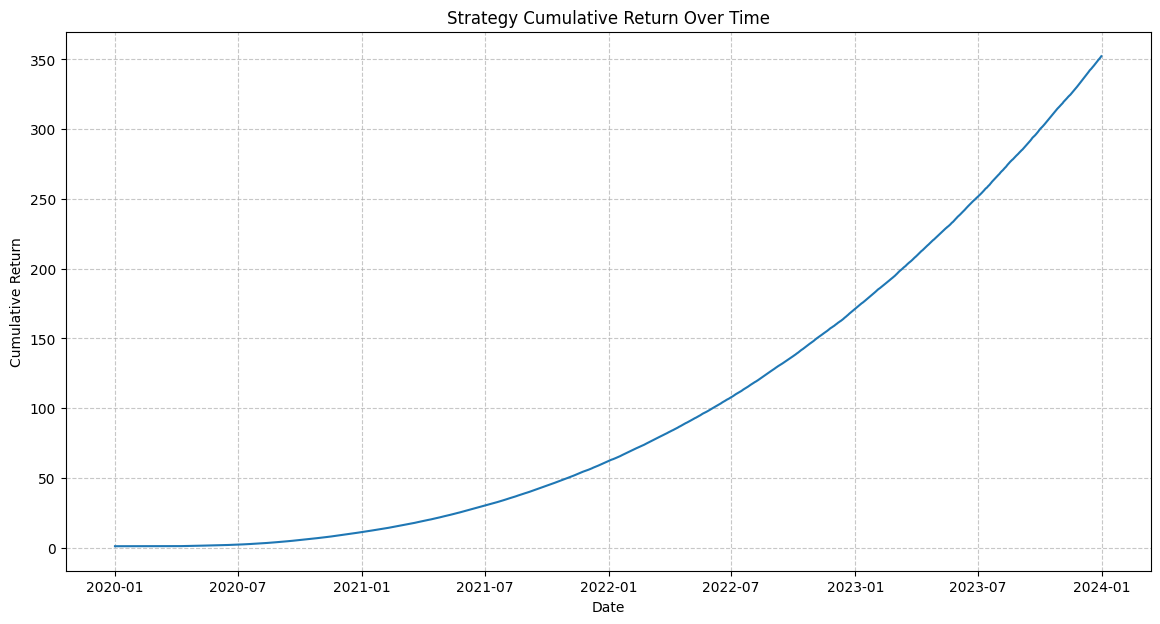

In [5]:
plt.figure(figsize=(14, 7))
sns.lineplot(x=results.index, y=results['cum_return'])
plt.title('Strategy Cumulative Return Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4. 백테스트 성과 지표 출력
`Backtester` 클래스의 `performance` 메서드를 사용하여 최종 성과 지표를 확인합니다.

In [6]:
performance_metrics = backtester.performance(results['net_return'])

print("백테스트 성과 지표:")
for k, v in performance_metrics.items():
    print(f"{k}: {v:.4f}")

백테스트 성과 지표:
Annual Return: 1.7498
Annual Volatility: 0.0448
Sharpe Ratio: 39.0308
Max Drawdown: -0.0010


## 5. `weights` DataFrame 히트맵 시각화
`weights` DataFrame을 히트맵으로 시각화하여 시간에 따른 각 종목의 투자 비중 변화를 확인합니다.

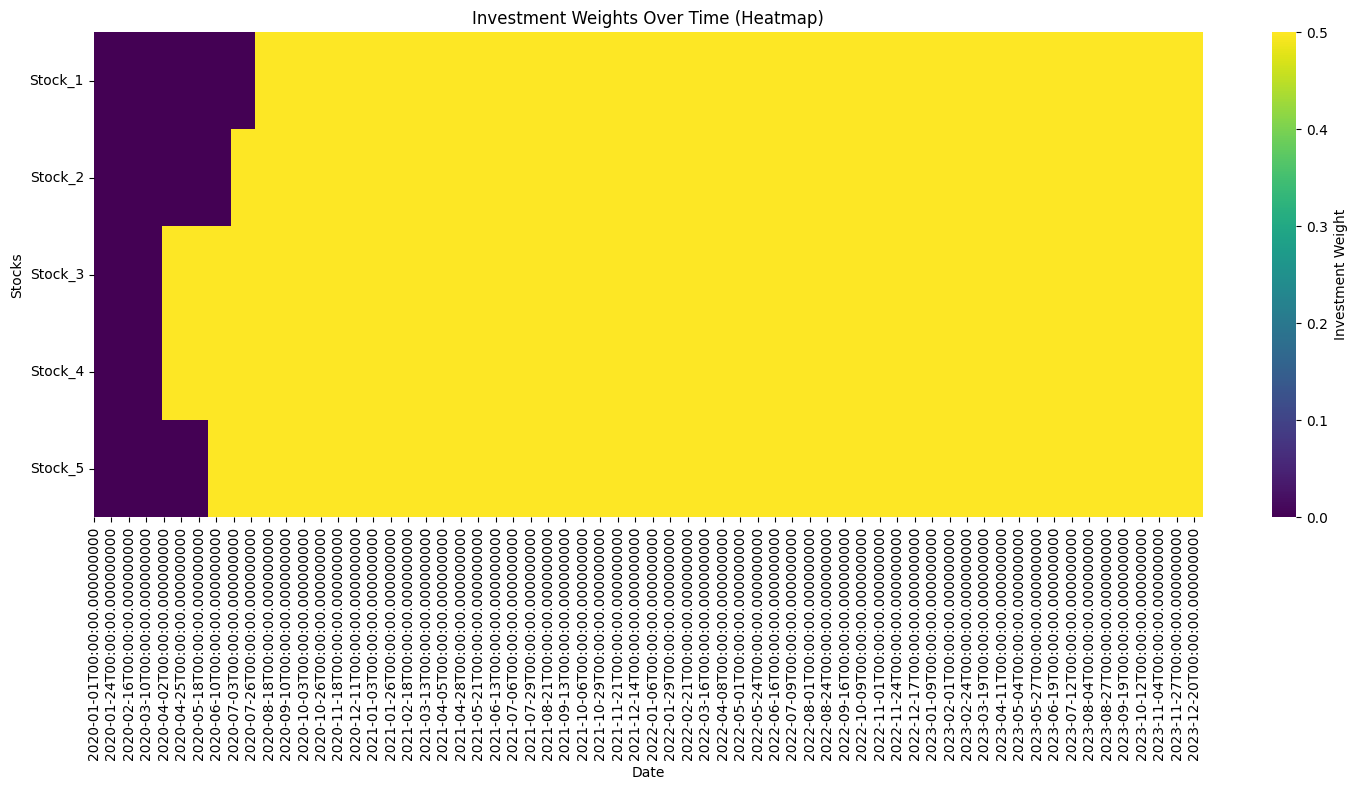

In [7]:
plt.figure(figsize=(15, 8))
sns.heatmap(weights.T, cmap='viridis', cbar_kws={'label': 'Investment Weight'})
plt.title('Investment Weights Over Time (Heatmap)')
plt.xlabel('Date')
plt.ylabel('Stocks')
plt.yticks(rotation=0) # Make stock names horizontal
plt.tight_layout()
plt.show()

## 6. 기간별 백테스트 성과 지표 출력
전체 기간이 아닌 특정 기간(예: 연도별)으로 나누어 백테스트 성과 지표를 다시 계산하고 출력합니다.

In [8]:
print("기간별 백테스트 성과 지표:")

# 연도별로 데이터를 분할하여 성과 지표 계산
for year in results.index.year.unique():
    yearly_returns = results[results.index.year == year]['net_return']

    if not yearly_returns.empty:
        yearly_performance = backtester.performance(yearly_returns)
        print(f"\n--- {year}년 성과 지표 ---")
        for k, v in yearly_performance.items():
            print(f"{k}: {v:.4f}")
    else:
        print(f"\n--- {year}년 데이터 없음 ---")

기간별 백테스트 성과 지표:

--- 2020년 성과 지표 ---
Annual Return: 4.2577
Annual Volatility: 0.0664
Sharpe Ratio: 64.1560
Max Drawdown: -0.0010

--- 2021년 성과 지표 ---
Annual Return: 2.2743
Annual Volatility: 0.0171
Sharpe Ratio: 132.7430
Max Drawdown: 0.0000

--- 2022년 성과 지표 ---
Annual Return: 1.0122
Annual Volatility: 0.0076
Sharpe Ratio: 132.5142
Max Drawdown: 0.0000

--- 2023년 성과 지표 ---
Annual Return: 0.6477
Annual Volatility: 0.0050
Sharpe Ratio: 130.2548
Max Drawdown: 0.0000


## 7. 기간별 백테스트 성과 지표 시각화
연도별로 계산된 성과 지표들을 막대 차트로 시각화하여 비교합니다.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 연도별 성과 지표를 저장할 리스트
performance_data = []

# 연도별로 데이터를 분할하여 성과 지표 계산 및 저장
for year in results.index.year.unique():
    yearly_returns = results[results.index.year == year]['net_return']

    if not yearly_returns.empty:
        yearly_performance = backtester.performance(yearly_returns)
        yearly_performance['Year'] = year # 연도 추가
        performance_data.append(yearly_performance)

# 리스트를 DataFrame으로 변환
performance_df = pd.DataFrame(performance_data)

display(performance_df)

,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Year
0,4.257685,0.066365,64.156050,-0.001,2020
1,2.274302,0.017133,132.743010,0.000,2021
2,1.012196,0.007638,132.514196,0.000,2022
3,0.647659,0.004972,130.254831,0.000,2023


/tmp/ipykernel_3936/1225064884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Annual Return', data=performance_df, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_3936/1225064884.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Annual Volatility', data=performance_df, ax=axes[0, 1], palette='plasma')
/tmp/ipykernel_3936/1225064884.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Sharpe Ratio', data=performance_df, ax=axes[1, 0], palette='magma')
/tmp/ipykernel_3936/1225064884.py:20: Future

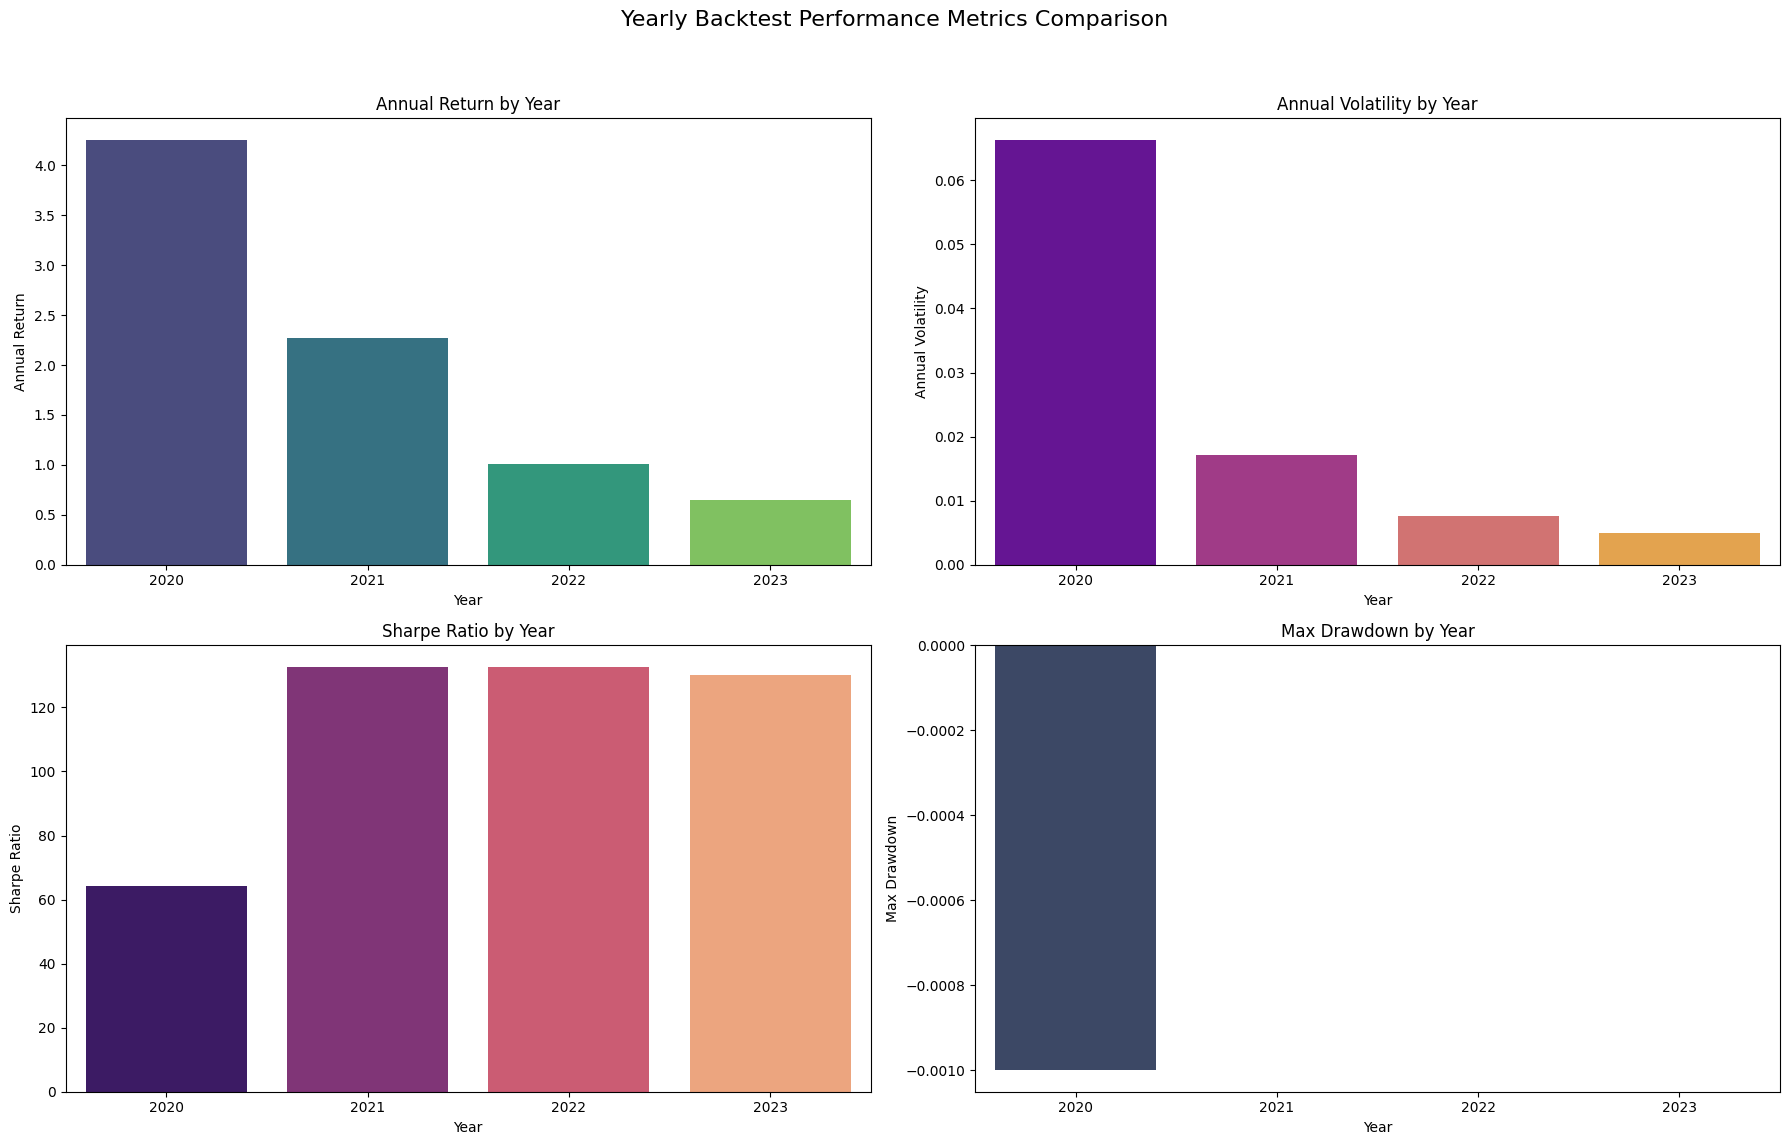

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Yearly Backtest Performance Metrics Comparison', fontsize=16)

# Annual Return
sns.barplot(x='Year', y='Annual Return', data=performance_df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Annual Return by Year')
axes[0, 0].set_ylabel('Annual Return')

# Annual Volatility
sns.barplot(x='Year', y='Annual Volatility', data=performance_df, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Annual Volatility by Year')
axes[0, 1].set_ylabel('Annual Volatility')

# Sharpe Ratio
sns.barplot(x='Year', y='Sharpe Ratio', data=performance_df, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Sharpe Ratio by Year')
axes[1, 0].set_ylabel('Sharpe Ratio')

# Max Drawdown
sns.barplot(x='Year', y='Max Drawdown', data=performance_df, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Max Drawdown by Year')
axes[1, 1].set_ylabel('Max Drawdown')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()